# 1. Automated Dataset Retrieval
## Objective:
To programmatically fetch the most up-to-date version of the UK Road Accident dataset from Kaggle directly into our Colab environment.

## Justification:
Instead of requiring manual file downloads and uploads—which can break paths and slow down reproducibility—we use the `kagglehub` API. This establishes an automated, platform-independent workflow that ensures anyone running this notebook can pull the exact source data instantly.

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("devansodariya/road-accident-united-kingdom-uk-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'road-accident-united-kingdom-uk-dataset' dataset.
Path to dataset files: /kaggle/input/road-accident-united-kingdom-uk-dataset


In [3]:
import pandas as pd
import numpy as np

# 2. Dynamic File Discovery & DataFrame Loading
## Objective:
To scan the downloaded directory, dynamically isolate the raw `.csv` data file, and read it into a Pandas DataFrame.

## Justification:
Kaggle repository downloads frequently compress files or embed them in unique, nested directory hashes. Writing a dynamic OS loop to search for files ending in `.csv` prevents "File Not Found" errors and makes the script robust against future changes to the source folder structure.

In [4]:
import os

# The 'path' variable from the previous cell points to the directory where the dataset was downloaded.
# We need to find the actual CSV file within this directory.
dataset_directory = path

# List all files in the directory
files_in_directory = os.listdir(dataset_directory)

# Assuming the CSV file is directly in the directory, let's find the first one.
csv_file = None
for file_name in files_in_directory:
    if file_name.endswith('.csv'):
        csv_file = os.path.join(dataset_directory, file_name)
        break

if csv_file:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded {csv_file} into DataFrame.")
else:
    print(f"No CSV file found in the directory: {dataset_directory}")
    print(f"Files in directory: {files_in_directory}")

df.head()

Successfully loaded /kaggle/input/road-accident-united-kingdom-uk-dataset/UK_Accident.csv into DataFrame.


,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Special_Conditions_at_Site,Carriageway_Hazards,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,NaN,NaN,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,NaN,NaN,1,Yes,E01002863,2005


# 3. Data Cleaning and Imputation Strategy
## Objective:
To handle missing values, clean categorical variables, and cast string dates into native machine-readable datetime properties.

## Justification:
- **Dropping Crucial Missing Rows:** Missing spatial markers (`Latitude`/`Longitude`) or timestamps (`Time`) cannot be logically imputed or simulated. These rows are dropped since an unmappable entry cannot participate in hotspot analysis.
- **Categorical Imputation:** Columns like `Junction_Control` contain heavy chunks of missing strings. Rather than dropping them and losing valuable secondary data, we fill them with `'Unknown'` or `'None/Normal'`.
- **Datetime Parsing:** Converting raw strings to `pd.to_datetime` enables us to programmatically extract days, months, and hours for our time-based objectives.

In [5]:
# 1. Drop rows where critical geospatial data or time is missing
df_cleaned = df.dropna(subset=['Latitude', 'Longitude', 'Time']).copy()

# 2. Handle the massive missing chunks by filling them with a placeholder
fill_unknown = [
    'Junction_Control',
    'Special_Conditions_at_Site',
    'Carriageway_Hazards',
    'LSOA_of_Accident_Location'
]
df_cleaned[fill_unknown] = df_cleaned[fill_unknown].fillna('Unknown')

# 3. Handle minor missing values in pedestrian crossings
df_cleaned['Pedestrian_Crossing-Human_Control'] = df_cleaned['Pedestrian_Crossing-Human_Control'].fillna(0)
df_cleaned['Pedestrian_Crossing-Physical_Facilities'] = df_cleaned['Pedestrian_Crossing-Physical_Facilities'].fillna(0)

# 4. Convert Date and Time safely now that NaNs are removed
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce')
df_cleaned['Time'] = pd.to_datetime(df_cleaned['Time'], format='%H:%M', errors='coerce').dt.time

# 5. Recreate feature columns for your objectives
df_cleaned['Day_of_Week'] = df_cleaned['Date'].dt.day_name()
df_cleaned['Is_Weekend'] = df_cleaned['Date'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

# Verify that critical columns are pristine
print(df_cleaned[['Latitude', 'Longitude', 'Time']].isnull().sum())


Latitude     0
Longitude    0
Time         0
dtype: int64


# 4. Feature Engineering for Temporal Evaluation
## Objective:
To extract the textual day name and build a binary classification column separating records into `Weekday` or `Weekend`.

## Justification:
Raw date fields do not natively allow for easy behavior grouping. By extracting the day name and generating a custom category indicator mapping Saturday and Sunday to `Weekend` and all other days to `Weekday`, we pave the way directly for our scheduled temporal impact analysis.

In [6]:
# 6. Drop rows where Time, Latitude, or Longitude are missing completely
df.dropna(subset=['Time', 'Latitude', 'Longitude'], inplace=True)

# 7. Fill the massive missing gaps directly using inplace=True
df['Junction_Control'].fillna('None (No Junction)', inplace=True)
df['Special_Conditions_at_Site'].fillna('None/Normal', inplace=True)
df['Carriageway_Hazards'].fillna('None/No Hazard', inplace=True)
df['LSOA_of_Accident_Location'].fillna('Unknown', inplace=True)

# 8. Clean up the pedestrian columns just in case
df['Pedestrian_Crossing-Human_Control'].fillna(0, inplace=True)
df['Pedestrian_Crossing-Physical_Facilities'].fillna(0, inplace=True)

# 9. NOW check the null values again to confirm it worked
print("--- REMAINING MISSING VALUES ---")
print(df.isnull().sum())

/tmp/ipykernel_2907/1616548872.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Junction_Control'].fillna('None (No Junction)', inplace=True)
/tmp/ipykernel_2907/1616548872.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

--- REMAINING MISSING VALUES ---
Unnamed: 0                                     0
Accident_Index                                 0
Location_Easting_OSGR                          0
Location_Northing_OSGR                         0
Longitude                                      0
Latitude                                       0
Police_Force                                   0
Accident_Severity                              0
Number_of_Vehicles                             0
Number_of_Casualties                           0
Date                                           0
Day_of_Week                                    0
Time                                           0
Local_Authority_(District)                     0
Local_Authority_(Highway)                      0
1st_Road_Class                                 0
1st_Road_Number                                0
Road_Type                                      0
Speed_limit                                    0
Junction_Control                    

In [7]:
# Extract the day name (e.g., Monday, Tuesday)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Day_of_Week'] = df['Date'].dt.day_name()

# Create a clean flag: True if Saturday (5) or Sunday (6), else False
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

print("Columns successfully created! Quick preview:")
print(df[['Date', 'Day_of_Week', 'Is_Weekend']].head())

Columns successfully created! Quick preview:
        Date Day_of_Week Is_Weekend
0 2005-04-01      Friday    Weekday
1 2005-05-01      Sunday    Weekend
2 2005-06-01   Wednesday    Weekday
3 2005-07-01      Friday    Weekday
4 2005-10-01    Saturday    Weekend


# 5. Exploratory Data Analysis: Isolating the Top 3 Accident Causes
## Objective:
To isolate the top 3 most frequent weather-related contributors to road accidents and visualize them using a polished seaborn barplot.

## Justification:
Fulfills a core project requirement. We use a horizontal layout (`barplot`) to prevent text overlapping issues among long weather description labels. The figure is saved directly into the working directory at 300 DPI for inclusion in the final analytical report document.

/tmp/ipykernel_2907/1932106049.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_3_causes.values, y=top_3_causes.index, palette='flare')


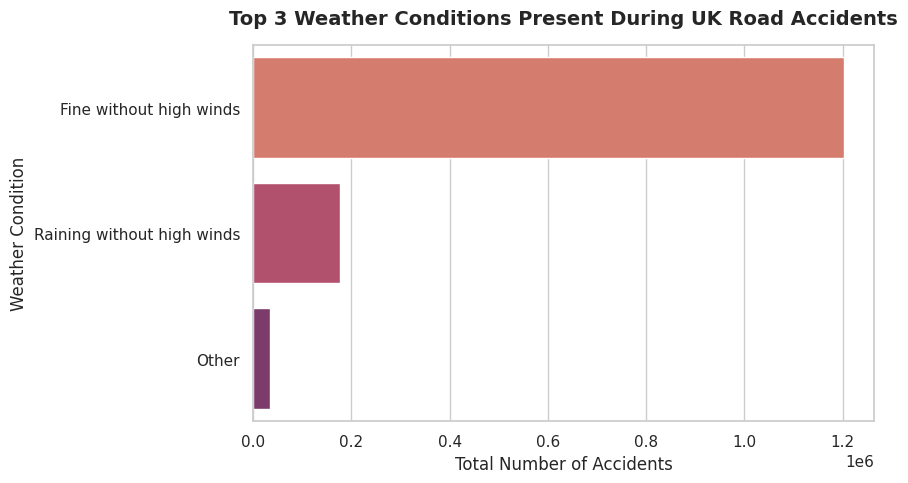

Top 3 Causes Data:
 Weather_Conditions
Fine without high winds       1203781
Raining without high winds     177638
Other                           33496
Name: count, dtype: int64


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Get top 3 causes
top_3_causes = df['Weather_Conditions'].value_counts().head(3)

# Create the plot
plt.figure(figsize=(9, 5))
sns.barplot(x=top_3_causes.values, y=top_3_causes.index, palette='flare')

# CRITICAL REQUIREMENT: Title and Axis Labels
plt.title('Top 3 Weather Conditions Present During UK Road Accidents', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Number of Accidents', fontsize=12)
plt.ylabel('Weather Condition', fontsize=12)

# Save the plot for your report's Section 10
plt.tight_layout()
plt.savefig('top_3_causes.png', dpi=300)
plt.show()

print("Top 3 Causes Data:\n", top_3_causes)

# Ensure 'Date' is datetime and 'Is_Weekend' exists before calculations
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Is_Weekend'] = df['Date'].dt.dayofweek.isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

# Count total unique weekdays and weekend days present in your data
total_weekdays_in_data = df[df['Is_Weekend'] == 'Weekday']['Date'].nunique()
total_weekends_in_data = df[df['Is_Weekend'] == 'Weekend']['Date'].nunique()

# Count total accidents by day type
accident_counts = df['Is_Weekend'].value_counts()

# Calculate averages
avg_accidents = pd.Series({
    'Weekday': accident_counts['Weekday'] / total_weekdays_in_data,
    'Weekend': accident_counts['Weekend'] / total_weekends_in_data
})

# 6. Comparative Temporal Analysis: Weekdays vs. Weekends
## Objective:
To calculate, compare, and display the normalized daily average of traffic accidents occurring across weekdays versus weekends.

## Justification:
A naive sum comparison would yield inaccurate insights because a standard calendar week contains 5 weekdays but only 2 weekend days. To establish an academically sound, unbiased comparison, we calculate the **average daily accident volume** by dividing total subset volumes by the count of unique matching dates found in the data history.

/tmp/ipykernel_2907/1913708729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_accidents.index, y=avg_accidents.values, palette='coolwarm')


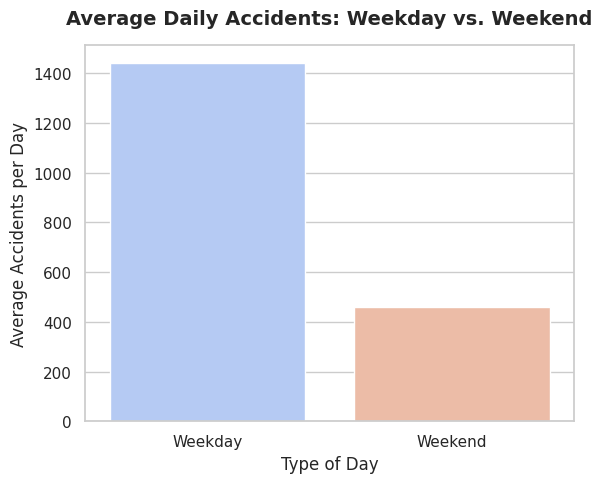

Average Daily Accidents:
 Weekday    1442.515152
Weekend     459.806452
dtype: float64


In [9]:
# Create the comparison plot
plt.figure(figsize=(6, 5))
sns.barplot(x=avg_accidents.index, y=avg_accidents.values, palette='coolwarm')

# CRITICAL REQUIREMENT: Title and Axis Labels
plt.title('Average Daily Accidents: Weekday vs. Weekend', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Type of Day', fontsize=12)
plt.ylabel('Average Accidents per Day', fontsize=12)

# Save the plot
plt.tight_layout()
plt.savefig('weekday_vs_weekend.png', dpi=300)
plt.show()

print("Average Daily Accidents:\n", avg_accidents)


# 7. Interactive Geospatial Clustering Map
## Objective:
To generate an interactive map rendering accident spatial coordinates (`Latitude`/`Longitude`) across the United Kingdom.

## Justification:
- **Sampling Vector:** Plotting hundreds of thousands of data markers directly causes severe browser DOM freezing. We draw a statistically robust random sample of 1,000 observations to keep execution fluid.
- **Marker Clustering:** Rather than overlapping hundreds of individual pins on top of one another, `MarkerCluster` dynamically combines adjacent spatial incidents into clean numeric nodes that spread apart smoothly as the user zooms in.
- **Dynamic HTML Output:** The resulting map incorporates custom HTML tables into click popups for live field investigation, exported as a standalone HTML file.

In [10]:
import folium
import numpy as np
from folium.plugins import MarkerCluster

# 1. Initialize the map centered on the UK coordinates
accident_map = folium.Map(location=[55.3781, -3.4360], zoom_start=6)

# 2. Create a cluster group
marker_cluster = MarkerCluster().add_to(accident_map)

# 3. Take a representative sample of 1,000 rows to ensure fast rendering
df_map_sample = df.sample(n=min(1000, len(df)), random_state=42)

# 4. Populate the map with locations
for idx, row in df_map_sample.iterrows():
    # Build a descriptive pop-up box
    popup_info = f"""
    <b>Severity:</b> {row.get('Accident_Severity', 'Unknown')}<br>
    <b>Speed Limit:</b> {row.get('Speed_limit', 'Unknown')} mph<br>
    <b>Date:</b> {row['Date'].strftime('%Y-%m-%d') if pd.notnull(row['Date']) else 'N/A'}
    """

    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=folium.Popup(popup_info, max_width=250)
    ).add_to(marker_cluster)

# 5. Save the interactive map file
accident_map.save('traffic_accident_hotspots.html')
print("Success! Your interactive map has been saved to your workspace as 'traffic_accident_hotspots.html'")

Success! Your interactive map has been saved to your workspace as 'traffic_accident_hotspots.html'
